# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

In [2]:
#importing necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

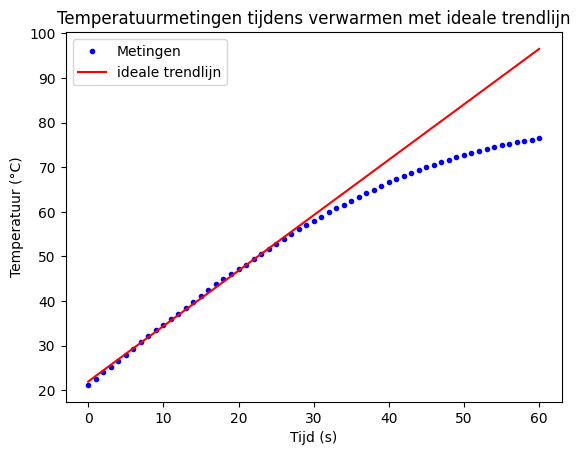

Vermogen verwarmingselement: P = 2452.74 ± 19.65 W
Begintemperatuur: T0 = 21.96 °C

Toegevoerde energie: 147.16 kJ
Energie voor opwarming: 109.33 kJ
Energie voor verdamping: 40.61 kJ
Opwarming + verdamping: 149.93 kJ
Verschil: 2.77 kJ
het verschil kan worden toegeschreven aan meetfouten.


In [ ]:
# inladen van de data
data = np.loadtxt("C:/Users/alder/Downloads/tempmetingen-46931600a9ec9432720d281e3972dd50.csv", dtype='float', skiprows=1, delimiter=';')

# scheiden van kolommen
tijd = data[:,0] #s
Temp = data[:,1] #°C

# gegeven massa's en constante
m_maatbeker = 820.8 #g
m_maatbeker_water_start = 1292.9 #g 
m_maatbeker_water_eind = 1274.9 #g

# berekenen van massa water en verdampte massa
m_water_start = 1292.9 - 820.8 #g
m_water_eind = 1274.9 - 820.8 #g
m_verdamping = m_water_start - m_water_eind #g
c_water = 4.18 #J/gK

#formule soortlijke warmte
# P = m*c*(dT/dt) => T(t) = (P/(m*c))*t + T0

#definitie lineaire fit functie
def lineaire_fit(t, P, T_0):
    return (P/(m_water_start*c_water))*t + T_0

#selectie data voor lineaire fit (eerste 30 seconden)
lim = tijd < 30

#uitvoeren curve fit voor ideale trendlijn
popt, pcov = curve_fit(lineaire_fit, tijd[lim], Temp[lim])
P_fit, T0_fit = popt
P_err = np.sqrt(pcov[0,0])

# plotten van de resultaten
plt.figure()
plt.plot(tijd, Temp, 'b.', label='Metingen')
plt.plot(tijd, lineaire_fit(tijd, P_fit, T0_fit), 'r-', label='ideale trendlijn')
plt.xlabel('Tijd (s)')
plt.ylabel('Temperatuur (°C)')
plt.title('Temperatuurmetingen tijdens verwarmen met ideale trendlijn')
plt.legend()
plt.show()

# resultaten weergeven
print(f"Vermogen verwarmingselement: P = {P_fit:.2f} ± {P_err:.2f} W")
print(f"Begintemperatuur: T0 = {T0_fit:.2f} °C")
print()

#aanname: alle toegevoerde warmte is gebruikt voor het verwarmen en verdampen van het water
#berekening toegevoerde warmte energie
Q_in = P_fit * tijd[-1] #Joule

#berekening opgewarmde warmte energie van het water
Delta_T = Temp.max() - Temp[0]
Q_opw = m_water_start * c_water * Delta_T  # J

#berekening verdampte warmte energie van het water
L_v = 2256  # J/g
Q_verd = m_verdamping * L_v  # J

#weergave resultaten
print(f"Toegevoerde energie: {Q_in/1000:.2f} kJ")
print(f"Energie voor opwarming: {Q_opw/1000:.2f} kJ")
print(f"Energie voor verdamping: {Q_verd/1000:.2f} kJ")
print(f"Opwarming + verdamping: {(Q_opw+Q_verd)/1000:.2f} kJ")
print(f"Verschil: {((Q_opw + Q_verd) - Q_in)/1000:.2f} kJ")



**Discussie**
